In [1]:
pip install seaborn==0.13.2


          date          coffee_name    money
0   2024-03-31            Americano  1044.80
1   2024-03-31  Americano with Milk  1154.00
2   2024-03-31           Cappuccino   780.50
3   2024-03-31                Cocoa   232.20
4   2024-03-31              Cortado   869.20
..         ...                  ...      ...
99  2025-03-31                Cocoa  1072.80
100 2025-03-31              Cortado    51.92
101 2025-03-31             Espresso   210.60
102 2025-03-31        Hot Chocolate   822.48
103 2025-03-31                Latte  2038.32

[104 rows x 3 columns]


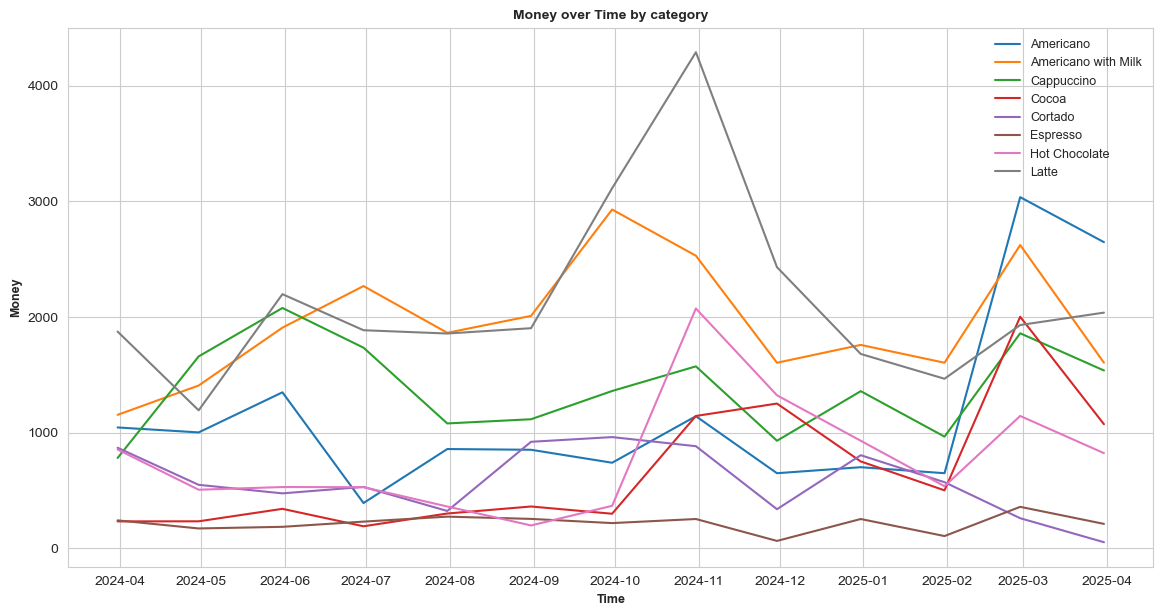

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df=pd.read_csv("index_1.csv")
df.set_index("datetime",inplace= True)
#print(df)
df["date"]=pd.to_datetime(df["date"])
#df1=df[["date","money"]]
df_month=df.groupby([pd.Grouper(key="date",freq="ME"),"coffee_name"])["money"].sum().reset_index()
print(df_month)
plt.figure(figsize=(14,7))
sns.set_style("whitegrid")
sns.lineplot(data=df_month,x="date",y="money",hue="coffee_name")
plt.xlabel("Time",fontsize=9, fontweight="bold")
plt.ylabel("Money",fontsize=9, fontweight="bold")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())   # Every month
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.title("Money over Time by category",fontsize=10,fontweight='bold')
#plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False, fontsize=9)
plt.show()

   cash_type          coffee_name     money
0       card            Americano  14650.26
1       card  Americano with Milk  24751.12
2       card           Cappuccino  17439.14
3       card                Cocoa   8521.16
4       card              Cortado   7384.86
5       card             Espresso   2690.28
6       card        Hot Chocolate   9933.46
7       card                Latte  26875.30
8       cash            Americano    412.00
9       cash  Americano with Milk    518.00
10      cash           Cappuccino    595.00
11      cash                Cocoa    157.00
12      cash              Cortado    150.00
13      cash             Espresso    124.00
14      cash        Hot Chocolate    239.00
15      cash                Latte    991.00


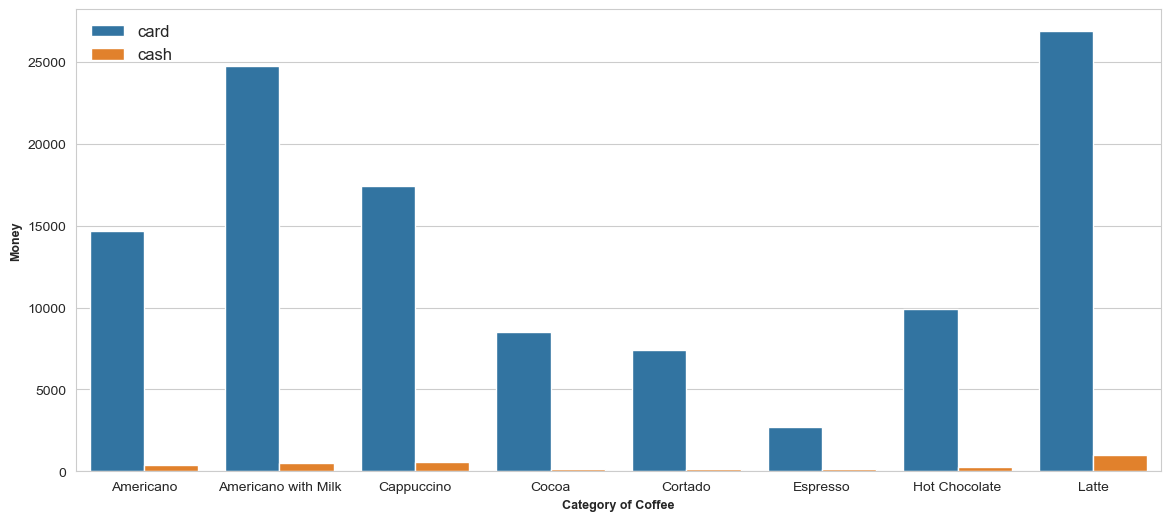

In [40]:
df=pd.read_csv("index_1.csv")
df.set_index("datetime",inplace= True)
#print(df)
df["date"]=pd.to_datetime(df["date"])
df_month=df.groupby(["cash_type","coffee_name"])["money"].sum().reset_index()
print(df_month)
plt.figure(figsize=(14,6))
sns.barplot(data=df_month,x="coffee_name",y="money",hue="cash_type")
plt.xlabel("Category of Coffee",fontsize=9,fontweight="bold")
plt.ylabel("Money",fontsize=9,fontweight="bold")
plt.legend(frameon=False, fontsize=12)
plt.show()

card
ANON-0000-0000-0012    129
ANON-0000-0000-0141    108
ANON-0000-0000-1163     77
ANON-0000-0000-0276     69
ANON-0000-0000-0009     67
ANON-0000-0000-0507     51
ANON-0000-0000-0040     50
ANON-0000-0000-0097     47
ANON-0000-0000-1110     33
ANON-0000-0000-1170     32
Name: count, dtype: int64


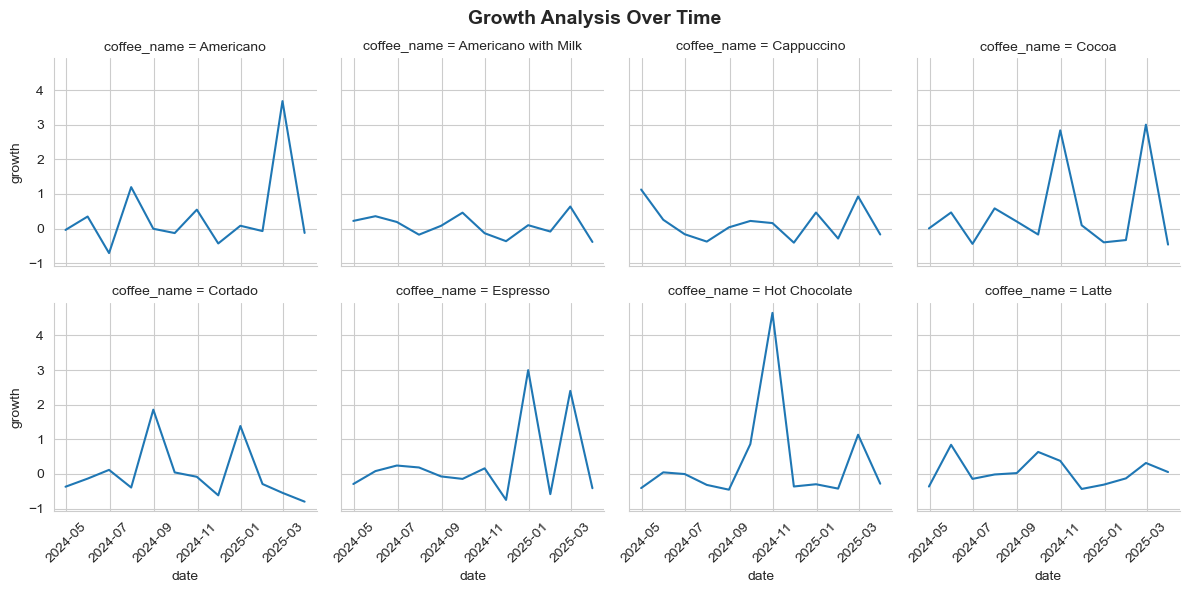

In [94]:
df=pd.read_csv("index_1.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
#df.set_index("datetime",inplace= True)
print(df["card"].value_counts().head(10))
monthly = df.groupby([pd.Grouper(key="date", freq="ME"),"coffee_name"])["money"].sum().reset_index()
monthly["growth"] =(monthly.groupby("coffee_name")["money"].pct_change())
monthly=monthly.dropna()
monthly.head(8)

g = sns.FacetGrid(monthly, col="coffee_name", col_wrap=4)
g.map(sns.lineplot, "date", "growth")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Growth Analysis Over Time", fontsize=14, fontweight="bold")
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.9)

In [91]:
total_sales=monthly["money"].sum()
print("Total sales = ",total_sales)
product_contribution=(monthly.groupby("coffee_name")["money"].sum())/total_sales
product_contribution=product_contribution*100
product_contribution

Total sales =  108381.38


coffee_name
Americano              12.933458
Americano with Milk    22.250243
Cappuccino             15.919377
Cocoa                   7.792815
Cortado                 6.150189
Espresso                2.374282
Hot Chocolate           8.597842
Latte                  23.981795
Name: money, dtype: float64

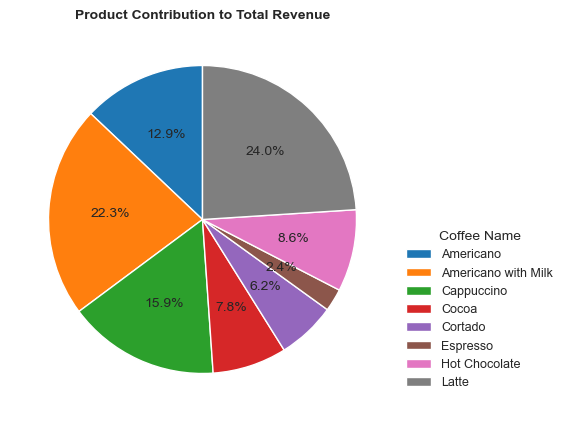

In [92]:
plt.figure(figsize=(5,5))

plt.pie(product_contribution,
        autopct="%1.1f%%",
        startangle=90)
plt.legend(product_contribution.index,
           title="Coffee Name",
           loc="best",frameon=False, fontsize=9,
           bbox_to_anchor=(1,0.5))

plt.title("Product Contribution to Total Revenue", fontsize=10,fontweight="bold")

plt.show()

In [68]:
import pandas as pd
df=pd.read_csv("index_1.csv")
#df=df.dropna()
df["cash_type"]=df["cash_type"].astype(str)
df["cash_type"] = df["cash_type"].apply(lambda x: 0 if x=="card" else 1)
#dff=df[df["cash_type"]=="card"]
#df=df.dropna()
df.drop(["card","datetime"],axis=1,inplace=True)
df.set_index("date",inplace=True)
print(df["coffee_name"].value_counts())
dff=df[df["coffee_name"]=="Latte"]
dff["money_1"]=dff["money"].diff()
#dff.dropna(inplace=True)
dff

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64


C:\Users\mohib\AppData\Local\Temp\ipykernel_8344\2705603663.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff["money_1"]=dff["money"].diff()


,cash_type,money,coffee_name,money_1
date,,,,
2024-03-01,0,38.70,Latte,NaN
2024-03-01,0,38.70,Latte,0.0
2024-03-02,1,40.00,Latte,1.3
2024-03-03,1,40.00,Latte,0.0
2024-03-03,0,38.70,Latte,-1.3
...,...,...,...,...
2025-03-21,0,35.76,Latte,0.0
2025-03-21,0,35.76,Latte,0.0
2025-03-22,0,35.76,Latte,0.0


In [69]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(dff["money"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Number of observations:", result[3])

for key, value in result[4].items():
    print("Critical Value", key, ":", value)

ADF Statistic: -1.9294569231765106
p-value: 0.3183330230375807
Used lags: 6
Number of observations: 775
Critical Value 1% : -3.4388159246521433
Critical Value 5% : -2.865276554696385
Critical Value 10% : -2.5687597090530696


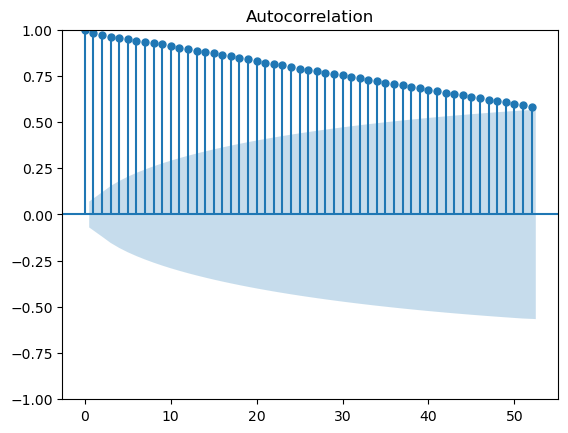

In [59]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(dff["money"],lags=52)
plt.show()

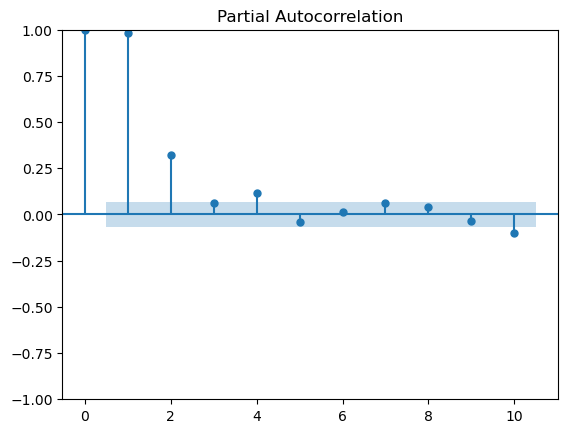

In [61]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(dff["money"],lags=10)
plt.show()

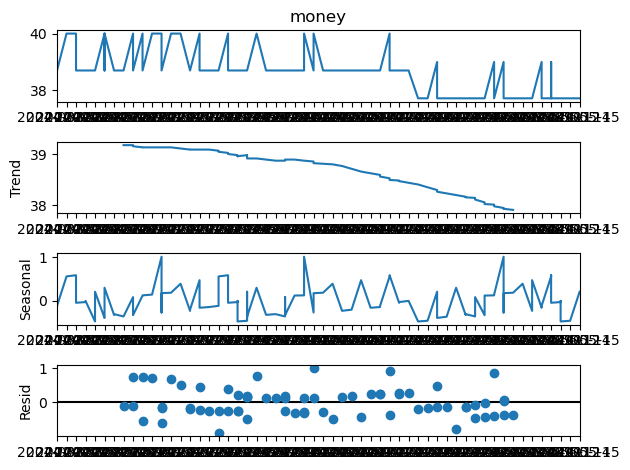

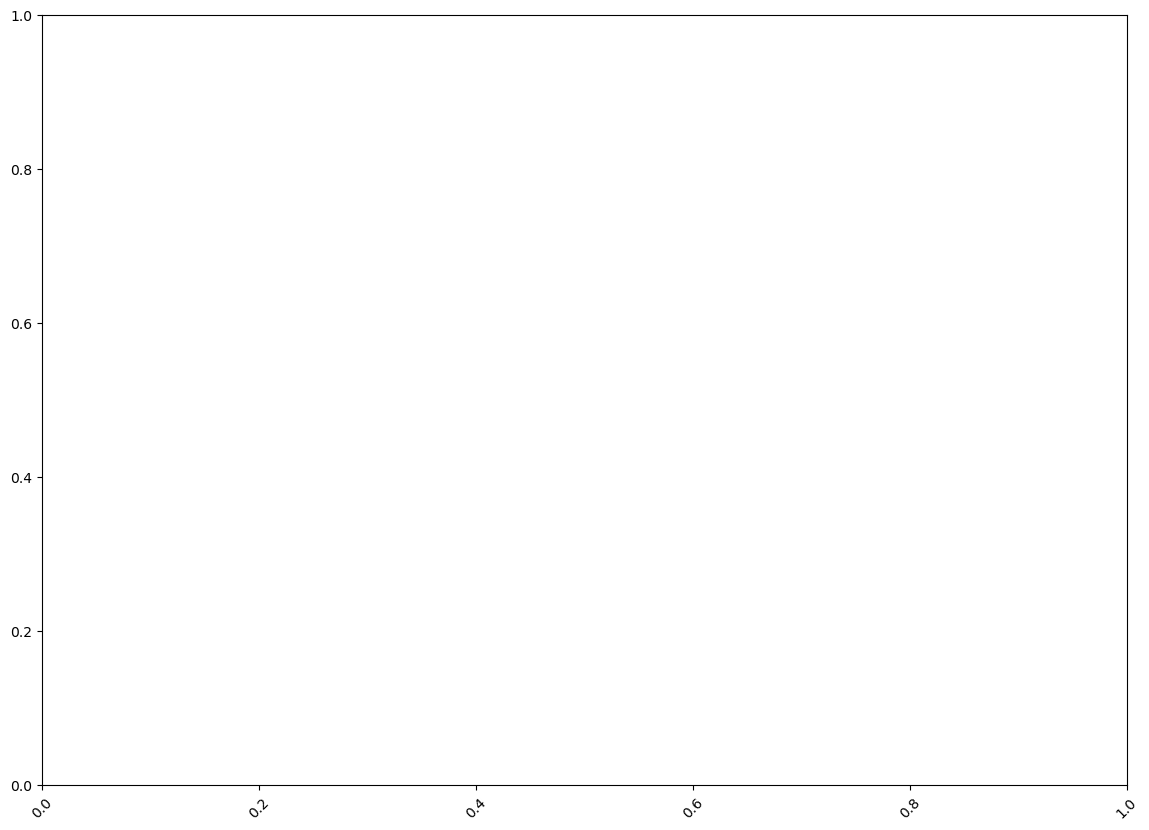

In [74]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decomp_results = seasonal_decompose(dff["money"][:100],model="additive", period=30)
decomp_results.plot()
plt.figure(figsize=(14,10))
plt.xticks(rotation=45)
plt.show()